In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
nhts = pd.read_csv("NHTS.csv")
ngsim = pd.read_csv("NGSIM.csv")

# Preview
print(nhts.head())
print(ngsim.head())

   household_id census_division census_region  driver_count  \
0    9000013002     New England     Northeast             2   
1    9000013002     New England     Northeast             2   
2    9000013016     New England     Northeast             2   
3    9000013039     New England     Northeast             2   
4    9000013041     New England     Northeast             1   

     household_income  household_size  household_workers  \
0    $175,000 or more               4                  1   
1    $175,000 or more               4                  1   
2  $75,000 to $99,999               2                  2   
3  $75,000 to $99,999               4                  1   
4    $175,000 or more               1                  1   

                            home_type household_location  \
0                 One-family detached              Urban   
1                 One-family detached              Urban   
2  Building with 2 or more apartments              Urban   
3  Building with 2 o

In [2]:
# Drop missing values 
nhts = nhts.dropna()
ngsim = ngsim.dropna()

# Convert time column 
ngsim['Time'] = pd.to_numeric(ngsim['Time'])

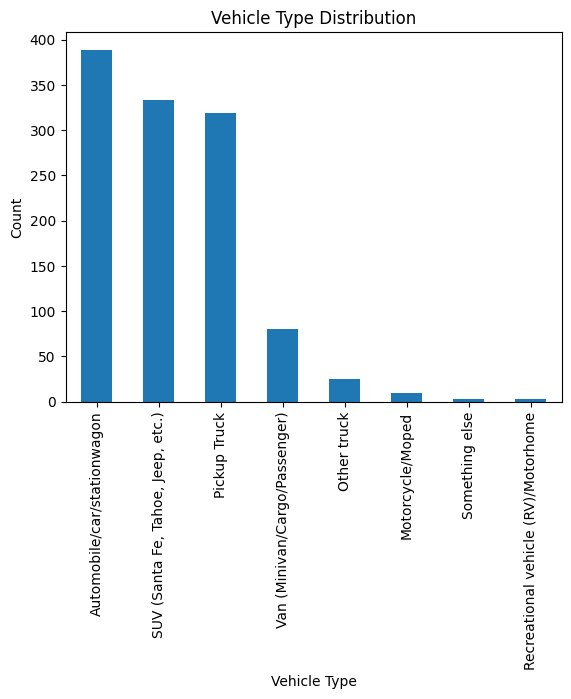

In [3]:
#This shows which types of vehicles are most common in households.

vehicle_counts = nhts['vehicle_type'].value_counts()

plt.figure()
vehicle_counts.plot(kind='bar')
plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

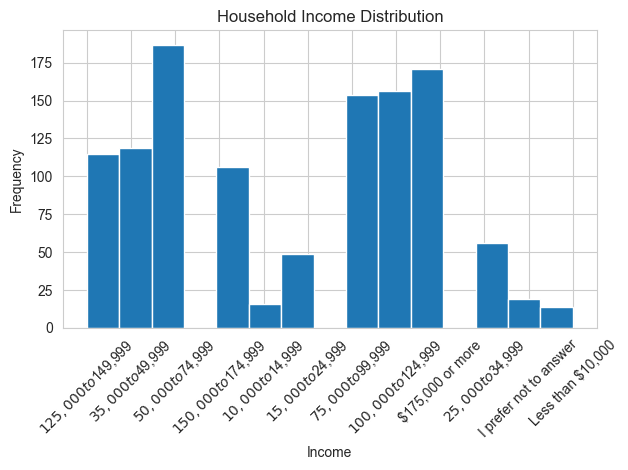

In [29]:
#Shows how income is spread across households

plt.figure()
plt.hist(nhts['household_income'], bins=15)

plt.title("Household Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

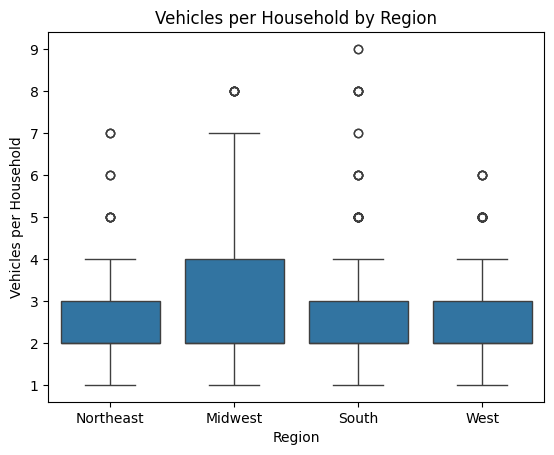

In [5]:
#Compares how vehicle ownership differs by region
plt.figure()
sns.boxplot(x='census_region', y='vehicles_per_household', data=nhts)
plt.title("Vehicles per Household by Region")
plt.xlabel("Region")
plt.ylabel("Vehicles per Household")
plt.show()

C:\Users\chase\AppData\Local\Temp\ipykernel_39076\1679358425.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traj['leader_smooth'] = traj['leader_speed(m/s)'].rolling(window=10).mean()
C:\Users\chase\AppData\Local\Temp\ipykernel_39076\1679358425.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traj['follower_smooth'] = traj['follower_speed(m/s)'].rolling(window=10).mean()


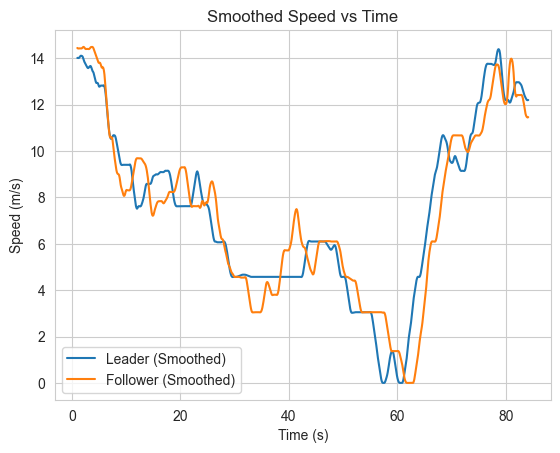

In [23]:
#Smoothed Speed vs Time 
#Due to the large size of the NGSIM dataset, initial plots appeared cluttered and difficult to interpret. 
#Smoothed data makes the graph visaully appealing and easily readable 
traj = ngsim[ngsim['trajectory_number'] == 1]

traj['leader_smooth'] = traj['leader_speed(m/s)'].rolling(window=10).mean()
traj['follower_smooth'] = traj['follower_speed(m/s)'].rolling(window=10).mean()

plt.figure()
plt.plot(traj['Time'], traj['leader_smooth'], label='Leader (Smoothed)')
plt.plot(traj['Time'], traj['follower_smooth'], label='Follower (Smoothed)')
plt.title("Smoothed Speed vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.show()

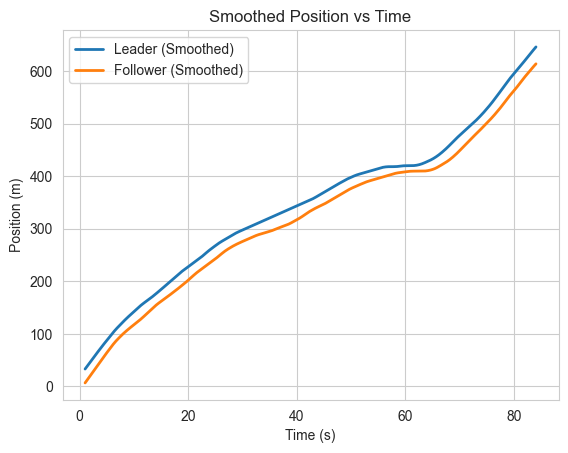

In [24]:
#Position vs Time
#Due to the large size of the NGSIM dataset, initial plots appeared cluttered and difficult to interpret.
#So, smoothed data makes the graph visually appealing and easily readable. 
traj = ngsim[ngsim['trajectory_number'] == 1].copy()

# Create smoothed position data
traj['leader_pos_smooth'] = traj['leader_position(m)'].rolling(window=10).mean()
traj['follower_pos_smooth'] = traj['follower_position(m)'].rolling(window=10).mean()

plt.figure()

# Plot smoothed lines
plt.plot(traj['Time'], traj['leader_pos_smooth'], label='Leader (Smoothed)', linewidth=2)
plt.plot(traj['Time'], traj['follower_pos_smooth'], label='Follower (Smoothed)', linewidth=2)

plt.title("Smoothed Position vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

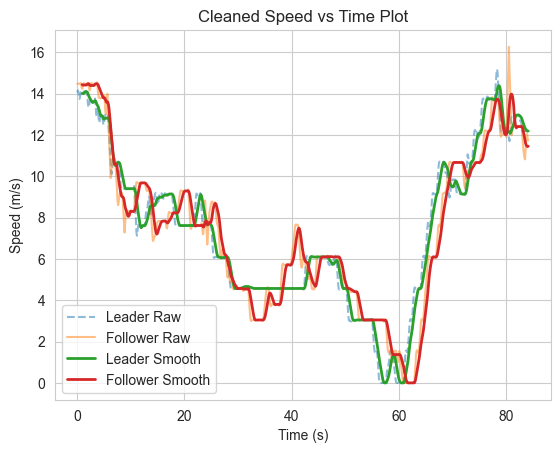

In [25]:
#Customized Plot  

# Set the visual style of the plot (adds grid background for better readability)
sns.set_style("whitegrid")

# Select only one trajectory from the dataset to reduce clutter in the graph
traj = ngsim[ngsim['trajectory_number'] == 1]

# Create a new figure for the plot
plt.figure()

# Plot raw leader speed data (dashed line, slightly transparent)
plt.plot(traj['Time'], traj['leader_speed(m/s)'], 
         linestyle='--', alpha=0.5, label='Leader Raw')

# Plot raw follower speed data (transparent line)
plt.plot(traj['Time'], traj['follower_speed(m/s)'], 
         alpha=0.5, label='Follower Raw')

# Plot smoothed leader speed using a moving average (window = 10 points)
plt.plot(traj['Time'], 
         traj['leader_speed(m/s)'].rolling(10).mean(), 
         linewidth=2, label='Leader Smooth')

# Plot smoothed follower speed using a moving average
plt.plot(traj['Time'], 
         traj['follower_speed(m/s)'].rolling(10).mean(), 
         linewidth=2, label='Follower Smooth')

plt.title("Cleaned Speed vs Time Plot")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
# Show the final plot
plt.show()

In [31]:
#Basic IDM used in previous lab
import numpy as np
import matplotlib.pyplot as plt

# 1. Select a trajectory

traj_num = 1  # change this to any trajectory number you like
traj = ngsim[ngsim['trajectory_number'] == traj_num].copy()


# 2. IDM Parameters

v0 = 30       # desired velocity (m/s)
s0 = 2        # minimum spacing (m)
T = 1.5       # desired time headway (s)
a_max = 1.0   # maximum acceleration (m/s²)
b = 1.5       # comfortable deceleration (m/s²)
delta = 4     # acceleration exponent


# 3. Prepare simulation arrays

dt = 0.1  # time step (s), matches NGSIM
time = traj['Time'].values
n = len(time)

# Follower speed (simulated), starting at initial NGSIM speed
v_sim = np.zeros(n)
v_sim[0] = traj['follower_speed(m/s)'].values[0]

# Follower position (simulated)
x_sim = np.zeros(n)
x_sim[0] = traj['follower_position(m)'].values[0]

# Follower acceleration (simulated)
acc_sim = np.zeros(n)

# Leader speed and position
v_leader = traj['leader_speed(m/s)'].values
x_leader = traj['leader_position(m)'].values

# Follower actual acceleration from NGSIM
acc_follower_real = traj['follower_acc(m/s^2)'].values
acc_leader = traj['leader_acc(m/s^2)'].values


# 4. Run IDM Simulation

for i in range(1, n):
    # Current follower speed
    v = v_sim[i-1]
    
    # Gap to leader
    s = x_leader[i-1] - x_sim[i-1]
    
    # Relative speed (follower - leader)
    delta_v = v - v_leader[i-1]
    
    # Desired minimum gap
    s_star = s0 + v*T + (v*delta_v)/(2*np.sqrt(a_max*b))
    
    # IDM acceleration equation
    acc = a_max * (1 - (v/v0)**delta - (s_star/s)**2)
    
    # Update arrays
    acc_sim[i] = acc
    v_sim[i] = v + acc*dt
    x_sim[i] = x_sim[i-1] + v_sim[i]*dt

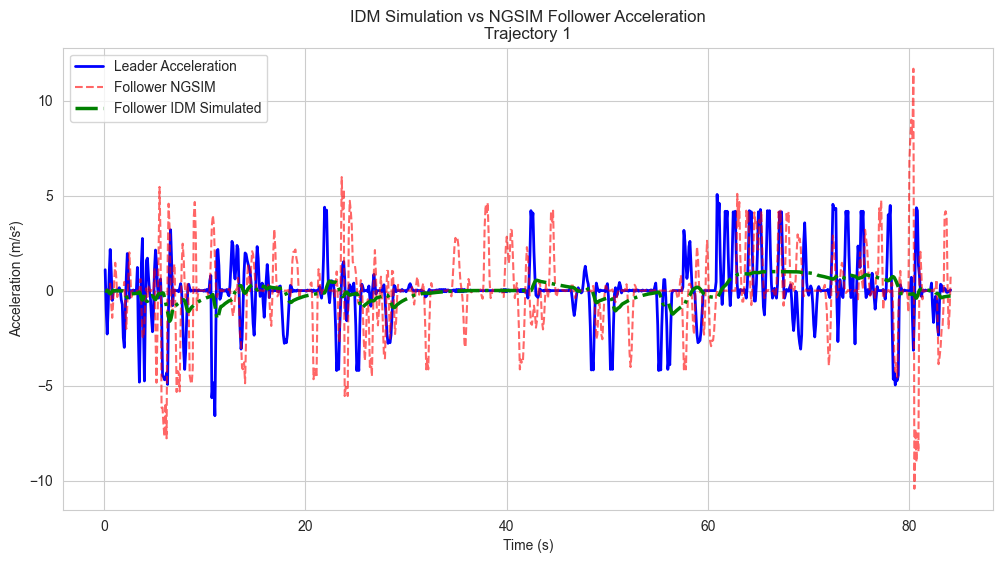

In [33]:
plt.figure(figsize=(12,6))

# Leader acceleration
plt.plot(time, acc_leader, color='blue', linestyle='-', linewidth=2, label='Leader Acceleration')

# Follower NGSIM (real) acceleration, semi-transparent
plt.plot(time, acc_follower_real, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Follower NGSIM')

# Follower IDM acceleration, bold and dashed-dot
plt.plot(time, acc_sim, color='green', linestyle='-.', linewidth=2.5, label='Follower IDM Simulated')

# Titles and labels
plt.title(f"IDM Simulation vs NGSIM Follower Acceleration\nTrajectory {traj_num}")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.legend()
plt.grid(True)
plt.show()